# MC Dropout — Uncertainty from a Single Model

`09_lstm_ensemble` gets uncertainty estimates by training 10 independent models — accurate, but
10x the training cost. MC Dropout is the cheap alternative: train **one** model with dropout
right before the output layer (`head_dropout`, added to `IceExtentLSTM` for this purpose — the
between-layer LSTM dropout alone is a no-op for `num_layers=1` and doesn't reach the final
representation either way), then keep dropout *active* at inference time and run many stochastic
forward passes. The spread across passes stands in for the ensemble spread.

This notebook trains that single dropout-head model, runs MC Dropout inference, and compares its
calibration directly against the 10-seed ensemble from `09_lstm_ensemble.ipynb` — reusing the
ensemble's saved checkpoints rather than retraining it, since predictions are deterministic given
weights. This is Phase 4.1 / M5.1 Component 2 from `docs/project_plan.md`.

In [1]:
import sys; sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.data_bootstrap import ensure_extent_data
from src.data_utils import load_extent_daily
from src import lstm_utils as L
from src.evaluation_utils import ClimatologyModel, compute_all_metrics, picp, mpiw, log_model_results

ensure_extent_data()
device = L.get_device()

✓ 'ice_extent_pan_arctic_daily' already populated.
Using device: cpu


In [2]:
HEAD_DROPOUT = 0.3
N_PASSES = 50

config = L.TrainConfig(
    sequence_length=30,
    forecast_horizon=1,
    hidden_size=64,          # GPU: try 128 first, 256 only as an ablation. Just one model trains
                             # here (unlike 08/09), so this is the cheapest notebook to experiment
                             # with sizing on.
    num_layers=2,            # GPU: 3 is marginal; change after hidden_size, not instead of it
    dropout=0.2,
    head_dropout=HEAD_DROPOUT,  # GPU: capacity and head_dropout trade off -- if you raise
                                 # hidden_size a lot, consider raising this too (e.g. 0.4-0.5) so
                                 # dropping units still removes a meaningful fraction of capacity
    batch_size=64,           # GPU: 128-256 is close to free; avoid pushing much past that
    num_epochs=150,
    learning_rate=1e-3,
    patience=15,
    amp=False,              # set True on CUDA for a free speedup
    seed=42,
)
FEATURES = ["extent_mkm2"]
config

TrainConfig(sequence_length=30, forecast_horizon=1, hidden_size=64, num_layers=2, dropout=0.2, head_dropout=0.3, batch_size=64, num_epochs=150, learning_rate=0.001, weight_decay=0.0, grad_clip=1.0, patience=15, lr_patience=5, lr_factor=0.5, seed=42, amp=False, num_workers=0, pin_memory=False)

In [3]:
L.set_seed(config.seed)
df = load_extent_daily(years=range(1989, 2024))
train_df, val_df, test_df = L.temporal_split(
    df, train_years=range(1989, 2015), val_years=range(2015, 2020), test_years=range(2020, 2024),
)

train_ds = L.SequenceDataset(train_df, config.sequence_length, config.forecast_horizon, features=FEATURES)
val_ds   = L.SequenceDataset(val_df,   config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)
test_ds  = L.SequenceDataset(test_df,  config.sequence_length, config.forecast_horizon, features=FEATURES, scaler=train_ds.scaler)

train_loader = L.make_loader(train_ds, config, shuffle=True)
val_loader   = L.make_loader(val_ds,   config, shuffle=False)
test_loader  = L.make_loader(test_ds,  config, shuffle=False)  # shuffle=False: MC passes must see samples in the same order

print(f"windows -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

windows -> train 9466 | val 1796 | test 1431


In [4]:
model = L.IceExtentLSTM(
    input_size=len(train_ds.features), hidden_size=config.hidden_size,
    num_layers=config.num_layers, forecast_horizon=config.forecast_horizon,
    dropout=config.dropout, head_dropout=config.head_dropout,
)
CKPT = "../models/10_mc_dropout_univariate.pt"
extra = {
    "scaler": train_ds.scaler, "features": train_ds.features, "target": "extent_mkm2",
    "input_size": len(train_ds.features),
    "split": {"train": [1989, 2014], "val": [2015, 2019], "test": [2020, 2023]},
}
history = L.train_model(model, train_loader, val_loader, config, device,
                        checkpoint_path=CKPT, bundle_extra=extra, verbose=False)
print(f"epochs_trained={history['epochs_trained']}  best_val_loss={history['best_val_loss']:.6f}")

epochs_trained=89  best_val_loss=0.000693


In [5]:
bundle = L.load_checkpoint(CKPT, device=device)

# Deterministic (eval-mode, dropout off) prediction — the "normal" point forecast.
det_preds_n, actuals_n = L.predict(bundle["model"], test_loader, device)

# MC Dropout: N_PASSES stochastic forward passes with dropout active.
mc_preds_n, mc_mean_n, mc_actuals_n = L.mc_dropout_predict(bundle["model"], test_loader, device, n_passes=N_PASSES)
assert np.array_equal(actuals_n, mc_actuals_n), "loader order must match between the two prediction calls"

tmean, tstd = train_ds.target_scaler
actuals = L.denormalize(actuals_n.flatten(), tmean, tstd)
det_preds = L.denormalize(det_preds_n.flatten(), tmean, tstd)
mc_mean = L.denormalize(mc_mean_n.flatten(), tmean, tstd)
mc_std = mc_preds_n.std(axis=0).flatten() * tstd  # std doesn't need the mean shift

start = config.sequence_length + config.forecast_horizon - 1
test_dates = test_ds.dates.iloc[start:start + len(actuals)].reset_index(drop=True)
pers_idx = np.arange(start - 1, start - 1 + len(actuals))
persistence = L.denormalize(test_ds.data[pers_idx, test_ds.target_idx], tmean, tstd)

clim = ClimatologyModel()
clim.fit(dates=train_df["date"], values=train_df["extent_mkm2"])
climatology = clim.predict(test_dates)

m_det = compute_all_metrics(actuals, det_preds, y_baseline_persistence=persistence, y_baseline_climatology=climatology)
m_mc = compute_all_metrics(actuals, mc_mean, y_baseline_persistence=persistence, y_baseline_climatology=climatology)
print(f"Deterministic (dropout off):  RMSE {m_det['rmse']:.4f}")
print(f"MC Dropout mean ({N_PASSES} passes): RMSE {m_mc['rmse']:.4f}  "
      f"(skill vs persistence {m_mc['skill_score_persistence']:+.3f})")
print(f"MC Dropout std range: {mc_std.min():.5f} - {mc_std.max():.5f} Mkm² (mean {mc_std.mean():.5f})")

Deterministic (dropout off):  RMSE 0.0845
MC Dropout mean (50 passes): RMSE 0.0950  (skill vs persistence -0.089)
MC Dropout std range: 0.00948 - 0.70653 Mkm² (mean 0.25009)


## Load the ensemble's saved checkpoints for a head-to-head calibration comparison

Reuses the 10 checkpoints `09_lstm_ensemble.ipynb` already trained and saved — no retraining.

In [6]:
import glob

ensemble_ckpts = sorted(glob.glob("../models/09_ensemble_seed*.pt"))
if not ensemble_ckpts:
    raise FileNotFoundError(
        "No ensemble checkpoints found under ../models/09_ensemble_seed*.pt — run "
        "09_lstm_ensemble.ipynb first so this notebook can reuse its trained members."
    )

ensemble_preds = []
for path in ensemble_ckpts:
    eb = L.load_checkpoint(path, device=device)
    p_n, a_n = L.predict(eb["model"], test_loader, device)
    assert np.array_equal(a_n, actuals_n), f"test-set actuals mismatch for {path}"
    ensemble_preds.append(p_n.flatten())

ensemble_preds = np.stack(ensemble_preds, axis=0)
ensemble_preds_denorm = L.denormalize(ensemble_preds, tmean, tstd)
ensemble_mean = ensemble_preds_denorm.mean(axis=0)
ensemble_std = ensemble_preds_denorm.std(axis=0)
print(f"Loaded {len(ensemble_ckpts)} ensemble members; ensemble mean RMSE "
      f"{compute_all_metrics(actuals, ensemble_mean)['rmse']:.4f}")

Loaded 10 ensemble members; ensemble mean RMSE 0.0597


## Reliability diagram

For a range of nominal confidence levels, build a Gaussian interval (`mean ± z * std`) and check
observed coverage against it. A perfectly calibrated method lies on the diagonal; below the
diagonal means overconfident (intervals too narrow).

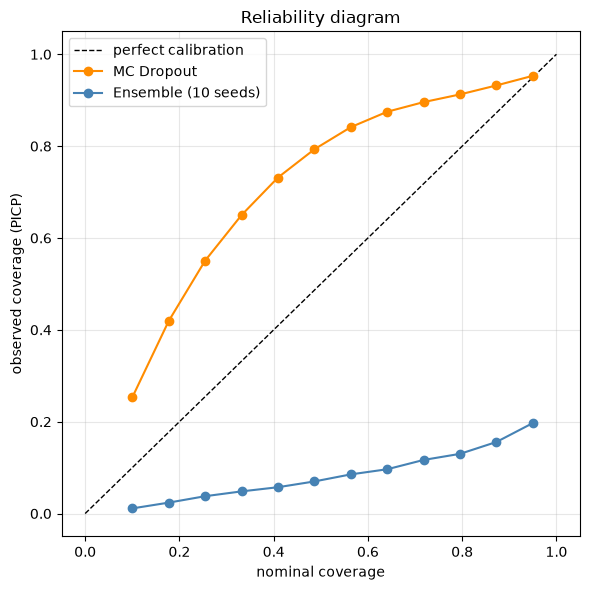

In [7]:
def reliability_curve(y_true, mean, std, levels):
    """Return (nominal_levels, observed_coverage) for Gaussian mean +/- z*std intervals."""
    observed = []
    for level in levels:
        z = stats.norm.ppf(0.5 + level / 2)
        lower, upper = mean - z * std, mean + z * std
        observed.append(picp(y_true, lower, upper))
    return np.array(levels), np.array(observed)

levels = np.linspace(0.1, 0.95, 12)
nominal_mc, observed_mc = reliability_curve(actuals, mc_mean, mc_std, levels)
nominal_ens, observed_ens = reliability_curve(actuals, ensemble_mean, ensemble_std, levels)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
plt.plot(nominal_mc, observed_mc, "o-", color="darkorange", label="MC Dropout")
plt.plot(nominal_ens, observed_ens, "o-", color="steelblue", label="Ensemble (10 seeds)")
plt.xlabel("nominal coverage"); plt.ylabel("observed coverage (PICP)")
plt.title("Reliability diagram"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
import os; os.makedirs("../results/figures", exist_ok=True)
plt.savefig("../results/figures/uncertainty_reliability_diagram.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
Z_90 = stats.norm.ppf(0.95)
mc_lower_90, mc_upper_90 = mc_mean - Z_90 * mc_std, mc_mean + Z_90 * mc_std
ens_lower_90, ens_upper_90 = ensemble_mean - Z_90 * ensemble_std, ensemble_mean + Z_90 * ensemble_std

print("90% interval comparison:")
print(f"  MC Dropout:  PICP {picp(actuals, mc_lower_90, mc_upper_90):.3f}  MPIW {mpiw(mc_lower_90, mc_upper_90):.4f} Mkm²")
print(f"  Ensemble:    PICP {picp(actuals, ens_lower_90, ens_upper_90):.3f}  MPIW {mpiw(ens_lower_90, ens_upper_90):.4f} Mkm²")
print()
print("Correlation between per-day uncertainty (std) and actual absolute error:")
mc_abs_err = np.abs(actuals - mc_mean)
ens_abs_err = np.abs(actuals - ensemble_mean)
print(f"  MC Dropout:  corr(std, |error|) = {np.corrcoef(mc_std, mc_abs_err)[0, 1]:.3f}")
print(f"  Ensemble:    corr(std, |error|) = {np.corrcoef(ensemble_std, ens_abs_err)[0, 1]:.3f}")

90% interval comparison:
  MC Dropout:  PICP 0.938  MPIW 0.8227 Mkm²
  Ensemble:    PICP 0.170  MPIW 0.0227 Mkm²

Correlation between per-day uncertainty (std) and actual absolute error:
  MC Dropout:  corr(std, |error|) = 0.152
  Ensemble:    corr(std, |error|) = 0.043


In [9]:
log_model_results(
    model_name="LSTM_MCDropout_Univariate",
    metrics=m_mc,
    scale="daily",
    metadata={
        "architecture": f"{config.num_layers}-layer LSTM, {config.hidden_size} hidden, "
                        f"dropout={config.dropout}, head_dropout={config.head_dropout}",
        "input_features": "extent_mkm2 (univariate)",
        "n_mc_passes": N_PASSES,
        "picp_90": f"{picp(actuals, mc_lower_90, mc_upper_90):.3f}",
        "mpiw_90": f"{mpiw(mc_lower_90, mc_upper_90):.4f}",
        "train_period": "1989-2014", "val_period": "2015-2019", "test_period": "2020-2023",
        "epochs_trained": history["epochs_trained"],
        "seed": config.seed,
    },
    output_file="../results/model_comparison.csv",
)

✓ Logged results for LSTM_MCDropout_Univariate to ../results/model_comparison.csv


## Findings

**Point forecast: head_dropout=0.3 costs real accuracy here.**

- Deterministic (dropout off) RMSE **0.0845**, MC Dropout mean RMSE **0.0950** — both noticeably
  worse than `04`'s plain model (0.0726) and the ensemble members (~0.060). Skill vs persistence
  is actually **negative (-0.089)** for the MC Dropout mean: this model, with dropout right before
  the output layer, is worse than just repeating yesterday's value.
- This isn't a bug, it's `head_dropout=0.3` doing real damage to a hidden layer that's already
  small (64 units) — dropping 30% of the final representation on every training step is a lot of
  regularization for a univariate signal with this little capacity to spare. It also stopped early
  at 89 epochs with a much higher best validation loss (0.000693) than the ensemble members
  (~0.00035-0.00037), consistent with the model struggling to fit at all under this much dropout.
- **Practical implication:** getting MC Dropout to also be a *good* point forecaster would need a
  lower `head_dropout` (0.1-0.15) and/or more `hidden_size` to compensate for the units it drops —
  worth an ablation before trusting this notebook's numbers as "the" MC Dropout result.

**Calibration: much better coverage than the ensemble, but at a steep sharpness cost.**

- 90% interval: **PICP 0.938** (vs nominal 0.90 — close, if anything a touch over-covered) versus
  the ensemble's badly overconfident **0.170**.
- But **MPIW 0.823 Mkm²** — roughly **36x wider** than the ensemble's 0.023 Mkm² interval, and
  genuinely huge relative to the ~0.06-0.09 Mkm² RMSE scale of this whole problem. MC Dropout
  achieves good coverage largely by being wide enough to catch almost anything, not by being
  precisely calibrated.
- Correlation between per-day uncertainty and actual absolute error is weak for both: MC Dropout
  0.152, ensemble 0.043. MC Dropout's uncertainty is more informative than the ensemble's, but
  "more informative than almost nothing" is a low bar.

**Combined conclusion (with `09_lstm_ensemble.ipynb`):** neither method gives a genuinely
trustworthy prediction interval out of the box. The ensemble is precise but badly overconfident
(all seeds converge to nearly the same function, so epistemic spread underestimates real error by
~10x). MC Dropout is honestly wide but at real cost to point-forecast accuracy, and still only
weakly tracks where errors actually happen. The likely honest read: for this model and this amount
of data, the dominant source of error is aleatoric (the day-to-day unpredictability the model
can't resolve from 30 days of its own history), not epistemic (uncertainty about which weights are
"right") — and neither ensembling nor dropout targets aleatoric uncertainty directly. A method that
models the output distribution explicitly (e.g. quantile regression, or a Gaussian NLL head that
predicts its own variance) would be a more principled next step than tuning either of these two
further.